# KNN Regression 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
#Load and clean data
df = sns.load_dataset('titanic')
df = df[['fare', 'pclass', 'sex', 'age', 'sibsp', 'parch']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

#Define X and y
X = df.drop('fare', axis=1)
y = df['fare']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Fit KNN Regressor
k = 5
knn = KNeighborsRegressor(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [9]:
#Predict and evaluate
y_pred = knn.predict(X_test_scaled)

print("R-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R-squared: 0.18809345441157876
MSE: 3380.201673501077


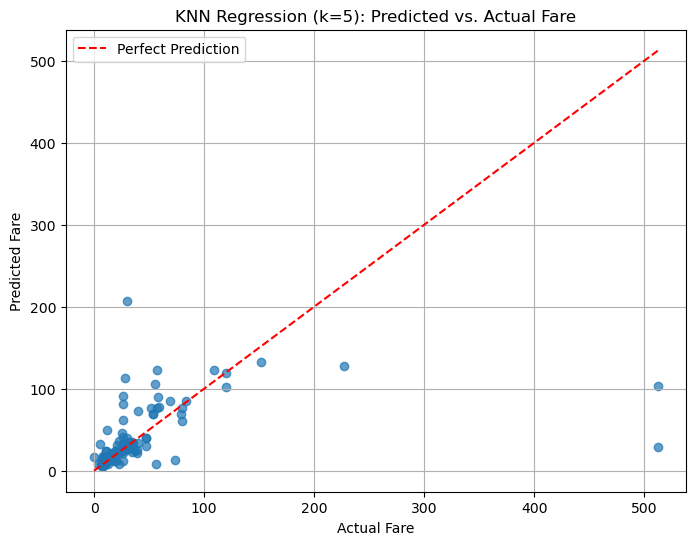

In [11]:
#Plot predicted vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title(f'KNN Regression (k={k}): Predicted vs. Actual Fare')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#OLS Regression For Comparison

import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_ols).fit()
y_pred_ols = ols_model.predict(X_test_ols)

print("R²:", r2_score(y_test, y_pred_ols))
print("MSE:", mean_squared_error(y_test, y_pred_ols))
print(ols_model.summary())

R²: 0.1784431994823229
MSE: 3420.378474684447
                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     91.83
Date:                Wed, 30 Jul 2025   Prob (F-statistic):           1.16e-70
Time:                        14:53:33   Log-Likelihood:                -2868.8
No. Observations:                 571   AIC:                             5750.
Df Residuals:                     565   BIC:                             5776.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

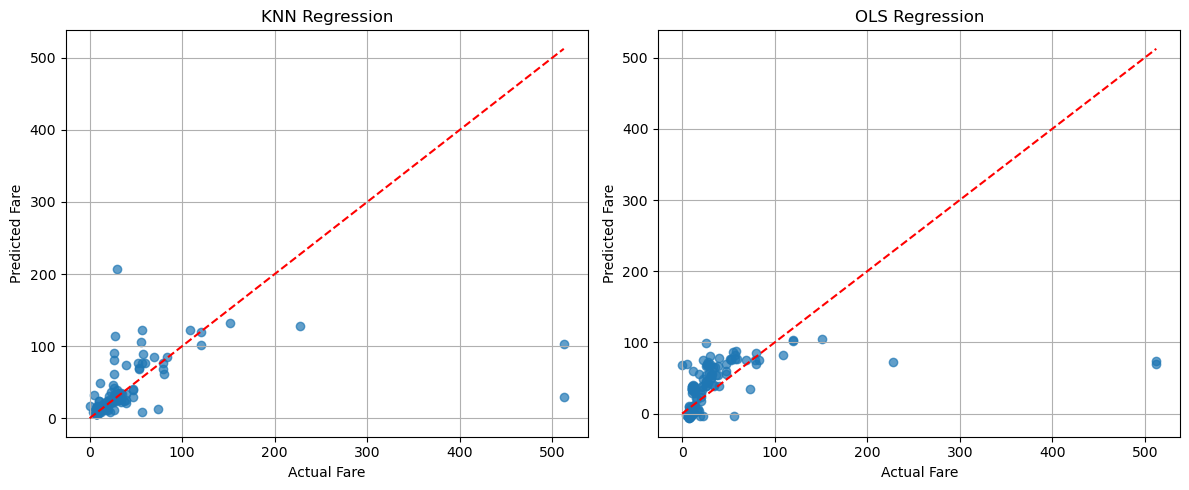

In [21]:
plt.figure(figsize=(12, 5))

#KNN
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.7, label='KNN Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('KNN Regression')
plt.grid(True)

#OLS
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ols, alpha=0.7, label='OLS Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('OLS Regression')
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:

#Predict a single example
sample_idx = 11
sample = X_test_scaled[sample_idx].reshape(1, -1)
neighbors = knn3.kneighbors(sample, return_distance=False)

print("Sample features:", X_test.iloc[sample_idx])
print("\nNearest Neighbors (indices):", neighbors)
print("\nNeighbor Fares:", y_train.iloc[neighbors[0]])


Sample features: pclass     2.0
sex        1.0
age       32.5
sibsp      0.0
parch      0.0
Name: 123, dtype: float64

Nearest Neighbors (indices): [[322 124 208]]

Neighbor Fares: 190    13.0
576    13.0
211    21.0
Name: fare, dtype: float64
